In [17]:
import joblib
import pandas as pd
import seaborn as sns
import sys
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, classification_report)

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_DIR))

from features import add_features
from data import load_data


pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Data Importing

In [18]:
model = joblib.load("../artifacts/model.joblib")

df = load_data("../data/raw/new_data.csv", target_column="Churn")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,label
0,Male,0,No,No,54,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.85,4308.25,0
1,Male,0,No,No,3,Yes,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,No,Credit card (automatic),74.45,221.10,0
2,Female,0,Yes,No,53,Yes,Yes,DSL,Yes,Yes,Yes,No,No,Yes,One year,No,Bank transfer (automatic),74.10,3833.95,0
3,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.35,69.35,1
4,Male,0,Yes,No,15,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,18.80,294.95,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            122 non-null    object 
 1   SeniorCitizen     122 non-null    int64  
 2   Partner           122 non-null    object 
 3   Dependents        122 non-null    object 
 4   tenure            122 non-null    int64  
 5   PhoneService      122 non-null    object 
 6   MultipleLines     122 non-null    object 
 7   InternetService   122 non-null    object 
 8   OnlineSecurity    122 non-null    object 
 9   OnlineBackup      122 non-null    object 
 10  DeviceProtection  122 non-null    object 
 11  TechSupport       122 non-null    object 
 12  StreamingTV       122 non-null    object 
 13  StreamingMovies   122 non-null    object 
 14  Contract          122 non-null    object 
 15  PaperlessBilling  122 non-null    object 
 16  PaymentMethod     122 non-null    object 
 1

In [20]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
label               0
dtype: int64

In [21]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...00222A1E52840>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

## Preprocessing

In [22]:
data = add_features(df)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,label,avg_charge,tenure_group,has_family,addon_count,normalize_addon,contract_risk
0,Male,0,No,No,54,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.85,4308.25,0,78.331818,very loyal,0,1,0.166667,2
1,Male,0,No,No,3,Yes,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,No,Credit card (automatic),74.45,221.10,0,55.275000,new,0,1,0.166667,2
2,Female,0,Yes,No,53,Yes,Yes,DSL,Yes,Yes,Yes,No,No,Yes,One year,No,Bank transfer (automatic),74.10,3833.95,0,70.999074,very loyal,1,4,0.666667,1
3,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.35,69.35,1,34.675000,new,0,0,0.000000,2
4,Male,0,Yes,No,15,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,18.80,294.95,0,18.434375,mid,1,0,0.000000,1


## Inference

In [23]:
X = df.drop(columns=["label"], errors='ignore')

pred = model.predict(X)
prob = model.predict_proba(X)[:, 1]

y_true = df["label"]

print("Accuracy:", accuracy_score(y_true, pred))
print("F1 Score:", f1_score(y_true, pred))
print("ROC AUC:", roc_auc_score(y_true, prob))

print("\nClassification Report:\n", classification_report(y_true, pred))

Accuracy: 0.7868852459016393
F1 Score: 0.5185185185185185
ROC AUC: 0.838423645320197

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.94      0.86        87
           1       0.74      0.40      0.52        35

    accuracy                           0.79       122
   macro avg       0.77      0.67      0.69       122
weighted avg       0.78      0.79      0.76       122



## Customer Retention Strategy

In [24]:
df["Churn Prob"] = prob
df["Churn Risk"] = pd.qcut(
    df["Churn Prob"],
    q=[0, 0.4, 0.7, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,label,Churn Prob,Churn Risk
0,Male,0,No,No,54,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.85,4308.25,0,0.264319,Medium Risk
1,Male,0,No,No,3,Yes,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,No,Credit card (automatic),74.45,221.10,0,0.498904,High Risk
2,Female,0,Yes,No,53,Yes,Yes,DSL,Yes,Yes,Yes,No,No,Yes,One year,No,Bank transfer (automatic),74.10,3833.95,0,0.051366,Low Risk
3,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.35,69.35,1,0.803113,High Risk
4,Male,0,Yes,No,15,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,18.80,294.95,0,0.044858,Low Risk


C:\Users\kim_c\AppData\Local\Temp\ipykernel_10332\653411923.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = df.groupby(["Churn Risk", "gender"]).size()


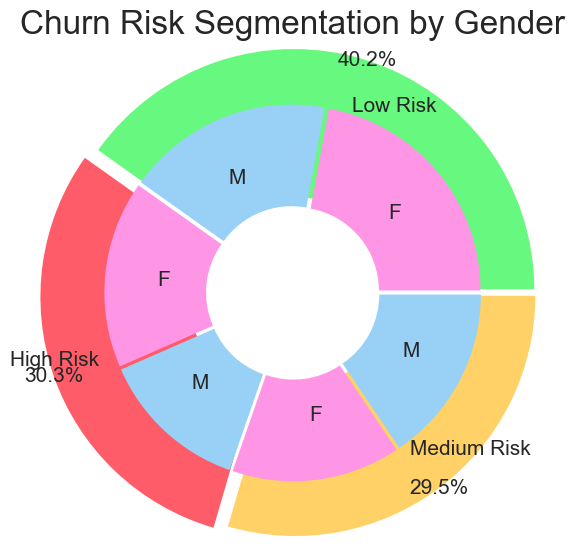

In [25]:
risk_counts = df['Churn Risk'].value_counts()
group_counts = df.groupby(["Churn Risk", "gender"]).size()

inner_labels = risk_counts.index
inner_sizes = risk_counts.values

outer_labels = [f"{gender[1][0]}" for gender in group_counts.index]
outer_sizes = group_counts.values

fig, ax = plt.subplots(figsize=(8,6))

ax.pie(
    inner_sizes,
    radius=1.3,
    labels=inner_labels,
    colors=["#67F87F", "#FF5C6A", "#FFD166"],  
    explode=[0.02,0.07,0.02],
    autopct='%1.1f%%',
    pctdistance=1.0,
    labeldistance=0.8,
    wedgeprops=dict(width=0.8, edgecolor='none'),
    textprops={'fontsize': 15}
)


ax.pie(
    outer_sizes,
    radius=1.0,
    labels=outer_labels,
    colors=["#ff95e5", "#99d1f6"] * (len(outer_sizes)//2),
    explode=[0.02]*len(outer_sizes),
    wedgeprops=dict(width=0.55, edgecolor='none'),
    labeldistance=0.65,
    textprops={'fontsize': 15}
)

ax.set_title("Churn Risk Segmentation by Gender", pad=20, fontsize=24)

plt.show()

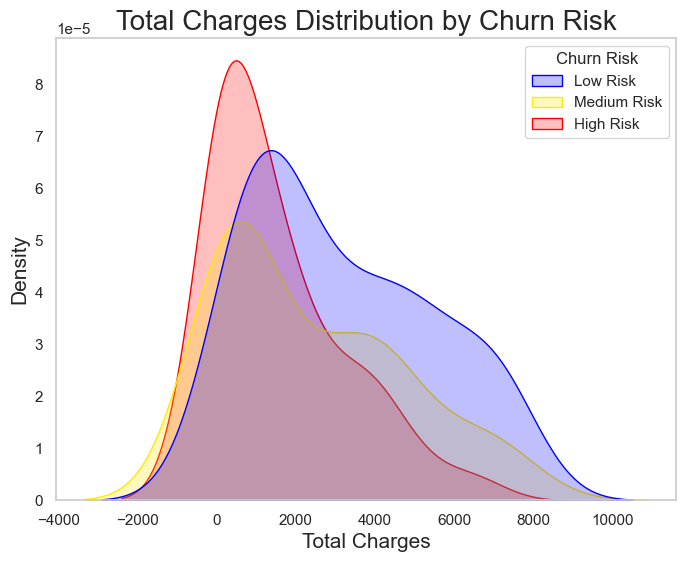

In [26]:
fig, ax = plt.subplots(figsize=(8,6))
ax = sns.kdeplot(data=df, x='TotalCharges', hue='Churn Risk', fill=True, palette=["#0000FF", "#FFEA00", "#FF0000"])
ax.grid(False)
ax.set_title("Total Charges Distribution by Churn Risk", fontsize=20)
ax.set_xlabel("Total Charges", fontsize=15)
ax.set_ylabel("Density", fontsize=15)
plt.show()


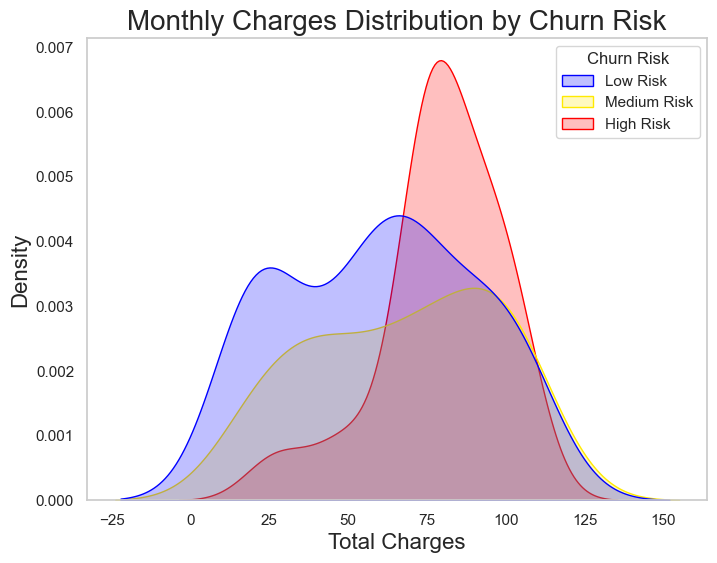

In [27]:
fig, ax = plt.subplots(figsize=(8,6))
ax = sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn Risk', fill=True, palette=["#0000FF", "#FFEA00", "#FF0000"])
ax.grid(False)
ax.set_title("Monthly Charges Distribution by Churn Risk", fontsize=20)
ax.set_xlabel("Total Charges", fontsize=16)
ax.set_ylabel("Density", fontsize=16)
plt.show()
